# Human mobility - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.

> Each prompt produces roughly the matching cell in the **Lane B** notebook.


## About this data source

**US Census LODES (ground mobility).** Every year the Census links *where people live* to
*where they work*, from employment records. Free, nationwide, down to the neighbourhood.
Think of it as: *"how many people sleep in county A and work in county B?"* That commuting
shed is the ground truth for which neighbours you exchange people with daily.

- **Explore it in a browser:** <https://onthemap.ces.census.gov/> (click a county, watch the
  arrows showing where its workers come from)
- Raw files: <https://lehd.ces.census.gov/data/>

**OpenFlights (air mobility).** A volunteer-built, open database of the world's airports and
airline routes. Not passenger counts, but the *wiring diagram* of global air travel, which is
how a distant outbreak becomes a local case.

- **Explore it in a browser:** <https://openflights.org/> (search an airport, see every route
  drawn on a world map)

> The gold standard here is GLEAM (Vespignani's lab), which uses licensed OAG/IATA and
> national commuting data. These two are the free stand-ins.


## Step 1: ground mobility

> *Using US Census LODES origin-destination data (LODES8, Georgia, JT00, 2021), for*
> *Fulton County GA (FIPS 13121), rank the counties that send the most commuters in.*
> *County = first 5 digits of the block geocode; sum the S000 column. Return the top 10*
> *as a tidy table with county names (use the Census national_county2020 lookup), and*
> *plot them. Note the file is ~22 MB, so cache the aggregate.*

**Your check:** do the top feeders look like the real commuter shed for that county?


Using cached LODES aggregate: ../data/lodes_fulton_inflow_top_counties.csv


,home_county_fips,home_county,commuters_to_fulton,share_pct
0,13121,"Fulton County, GA",234257,27.39
1,13089,"DeKalb County, GA",119060,13.92
2,13067,"Cobb County, GA",108147,12.65
3,13135,"Gwinnett County, GA",86184,10.08
4,13117,"Forsyth County, GA",37252,4.36
5,13063,"Clayton County, GA",36714,4.29
6,13057,"Cherokee County, GA",30456,3.56
7,13151,"Henry County, GA",24290,2.84
8,13097,"Douglas County, GA",17160,2.01
9,13223,"Paulding County, GA",15033,1.76


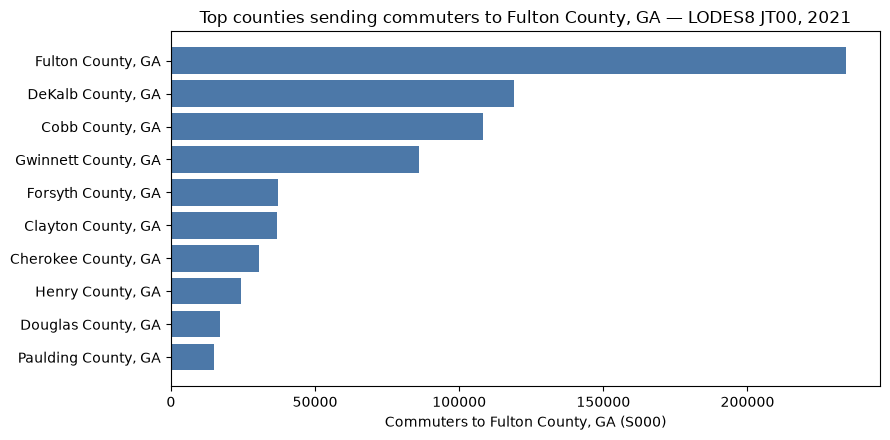

In [1]:
# Agent's LODES aggregation + plot:
from pathlib import Path
import csv, gzip, io
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import pandas as pd

TARGET_FIPS = '13121'  # Fulton County, GA
CACHE_NAME = 'lodes_fulton_inflow_top_counties.csv'
cache_candidates = [Path('../data') / CACHE_NAME, Path('data') / CACHE_NAME]
cache = next((path for path in cache_candidates if path.exists()), cache_candidates[0])
LIVE = False  # Set True to download LODES8 GA OD data and rebuild the cache.

def fetch(url, timeout=300):
    request = Request(url, headers={'User-Agent': 'SISMID2026-course/1.0'})
    return urlopen(request, timeout=timeout).read()

if LIVE:
    county_names = {}
    lookup = fetch('https://www2.census.gov/geo/docs/reference/codes2020/national_county2020.txt')
    for line in lookup.decode('utf-8', 'replace').splitlines()[1:]:
        parts = line.split('|')
        if len(parts) > 4:
            county_names[parts[1] + parts[2]] = f'{parts[4]}, {parts[0]}'

    url = 'https://lehd.ces.census.gov/data/lodes/LODES8/ga/od/ga_od_main_JT00_2021.csv.gz'
    inflow = {}
    with gzip.open(io.BytesIO(fetch(url)), 'rt') as file:
        for row in csv.DictReader(file):
            if row['w_geocode'][:5] == TARGET_FIPS:
                home_fips = row['h_geocode'][:5]
                inflow[home_fips] = inflow.get(home_fips, 0) + int(row['S000'])

    total = sum(inflow.values())
    ground = pd.DataFrame([
        {'home_county_fips': fips, 'home_county': county_names.get(fips, 'Unknown'),
         'commuters_to_fulton': commuters, 'share_pct': round(100 * commuters / total, 2)}
        for fips, commuters in sorted(inflow.items(), key=lambda item: item[1], reverse=True)[:15]
    ])
    ground.to_csv(cache, index=False)
else:
    print(f'Using cached LODES aggregate: {cache}')
    ground = pd.read_csv(cache, dtype={'home_county_fips': str})

top10 = ground.head(10).copy()
display(top10)

plt.figure(figsize=(9, 4.5))
plt.barh(top10['home_county'][::-1], top10['commuters_to_fulton'][::-1], color='#4C78A8')
plt.xlabel('Commuters to Fulton County, GA (S000)')
plt.title('Top counties sending commuters to Fulton County, GA — LODES8 JT00, 2021')
plt.tight_layout()
plt.show()


## Step 2: air mobility

> *I want the countries that connect to Atlanta (ATL) as a proxy for air-importation*
> *risk. Note the OpenSky API now needs a free account and OAuth2 (anonymous gets 403),*
> *so use the free OpenFlights routes.dat + airports.dat instead: count inbound routes*
> *to ATL by origin airport, map to country, and rank the top countries. Plot the top 10*
> *excluding domestic.*

**Your check:** routes measure *structure*, not passenger volume. What would you need to
turn this into real importation risk?


Using cached OpenFlights route table: ../data/openflights_atl_inbound.csv


,origin_country,inbound_routes
24,Mexico,44
16,Germany,15
39,United Kingdom,12
7,Canada,9
31,Puerto Rico,8
2,Bahamas,6
22,Jamaica,5
21,Italy,5
6,Brazil,4
15,France,4


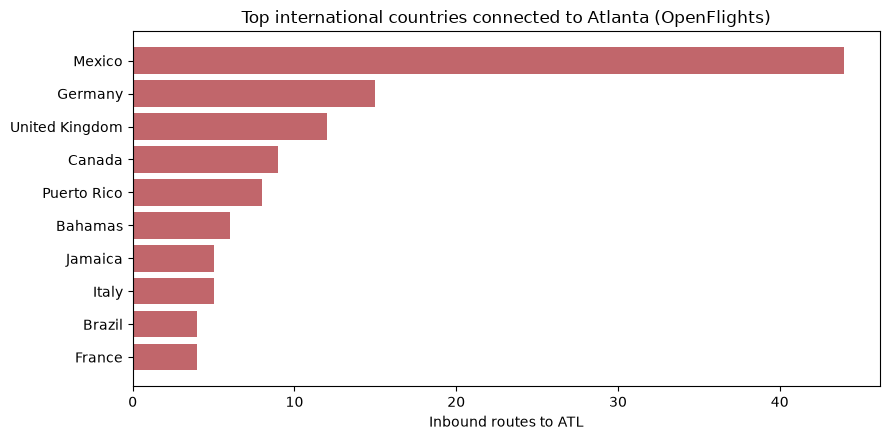

Routes measure network structure, not passenger volume or actual importations.


In [2]:
# Agent's OpenFlights connectivity:
import csv

AIRPORT = 'ATL'
CACHE_NAME = 'openflights_atl_inbound.csv'
cache_candidates = [Path('../data') / CACHE_NAME, Path('data') / CACHE_NAME]
cache = next((path for path in cache_candidates if path.exists()), cache_candidates[0])
LIVE = False  # Set True to rebuild the cached route table from OpenFlights.

if LIVE:
    airports = {}
    for line in fetch('https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat').decode('utf-8', 'replace').splitlines():
        row = next(csv.reader([line]))
        if len(row) > 4 and row[4] not in ('', r'\N'):
            airports[row[4]] = {'city': row[2], 'country': row[3]}

    inbound = {}
    for line in fetch('https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat').decode('utf-8', 'replace').splitlines():
        row = next(csv.reader([line]))
        if len(row) > 4 and row[4] == AIRPORT and row[2] in airports:
            origin = airports[row[2]]
            key = (origin['country'], row[2], origin['city'])
            inbound[key] = inbound.get(key, 0) + 1

    air = pd.DataFrame([
        {'origin_country': country, 'origin_airport': airport, 'origin_city': city, 'n_routes': routes}
        for (country, airport, city), routes in inbound.items()
    ])
    air.to_csv(cache, index=False)
else:
    print(f'Using cached OpenFlights route table: {cache}')
    air = pd.read_csv(cache)

top10_international = (air.loc[air['origin_country'].ne('United States')]
                         .groupby('origin_country', as_index=False)['n_routes'].sum()
                         .rename(columns={'n_routes': 'inbound_routes'})
                         .sort_values('inbound_routes', ascending=False)
                         .head(10))
display(top10_international)

plt.figure(figsize=(9, 4.5))
plt.barh(top10_international['origin_country'][::-1], top10_international['inbound_routes'][::-1], color='#C1666B')
plt.xlabel('Inbound routes to ATL')
plt.title('Top international countries connected to Atlanta (OpenFlights)')
plt.tight_layout()
plt.show()
print('Routes measure network structure, not passenger volume or actual importations.')


## Step 3: sanity-check and save

> *Report row counts for both tables, confirm the commuter shares sum sensibly, and save*
> *both to tidy CSVs.*


In [3]:
# Agent's checks + save:


## Reflection

- Ground = which neighbours seed you; air = which distant places import risk.
- Both are free proxies for GLEAM's licensed OAG / IATA / commuting data.
- Feeds the ARGONet network idea in the 1:30 session.
